In [1]:
import cv2
import matplotlib.pyplot as plt
import os
from xiaoying.toolkit.detect import detect_crop_align
from tqdm import tqdm
import torch
from xiaoying import net
from torchvision import transforms
from xiaoying.ViT.load_models import load_vit_base
import torch.nn as nn
from PIL import Image
import math

c:\MINH\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\PC/.insightface\models\buffalo_l\1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\PC/.insightface\models\buffalo_l\2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\PC/.insightface\models\buffalo_l\det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\PC/.insightface\models\buffalo_l\genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\PC/.insightface\models\buffalo_l\w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det

In [25]:
device = torch.device('cuda')
print(device)

vit = load_vit_base()
vit.load_state_dict(torch.load('C:\MINH\models\ViT_base.pth', map_location="cpu"))

class ViT(nn.Module):
    def __init__(self, model):
        super(ViT, self).__init__()
        self.model = model
        
    def forward(self, x):
        x = self.model(x)
        norm = torch.norm(x, 2, 1, True)
        output = torch.div(x, norm)
        return output, norm

model = ViT(vit)

model.to(device);

cuda
Loaded ViT model
compatible keys in state_dict 281 / 281
Check


<All keys matched successfully>
Loaded pretrained model from pretrained_model/model.pt


In [3]:
transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Resize((112, 112)),
        transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
    ])

In [48]:
def plot(results, suptitle, cols=6):
    n = len(results)
    rows = math.ceil(n / cols)

    plt.figure(figsize=(cols * 4, rows * 4))

    for i, (file, image) in enumerate(results.items()):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(image)
        plt.title(file)
        plt.axis('off')
        
    plt.suptitle(suptitle, fontsize=25, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [30]:
def split(results):
    images, targets = [], []
    for file, img in results.items():
        img = transform(img)
        if 'target' in file:
            targets.append(img)
        else:
            images.append(img)
            
    images = torch.stack(images)
    targets = torch.stack(targets)
            
    return images, targets

In [68]:
def ying(base):
    for subfolder in os.listdir(base):
        results = {}
        if os.path.isdir(os.path.join(base, subfolder)):
            for file in os.listdir(os.path.join(base, subfolder)):
                
                img_path = os.path.join(base, subfolder, file)
                img = cv2.imdecode(
                    np.fromfile(img_path, dtype=np.uint8),
                    cv2.IMREAD_COLOR
                )
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                
                
                processed_img = detect_crop_align(img)
                if len(processed_img) > 0:
                    results[file] = processed_img[0]
                    
        if len(results) > 0:         
            # plot           
            plot(results, subfolder)
            
            # split
            images, targets = split(results)
            
            model.eval()
            with torch.no_grad():
                embeddings, _ = model(images.to(device))
                target_embeddings, _ = model(targets.to(device))
            
            cosine = torch.cosine_similarity(
                torch.mean(embeddings, dim=0, keepdim=True),
                torch.mean(target_embeddings, dim=0, keepdim=True)
            )
            print("Mean Pooling: ", cosine)
                    
            cosines = torch.cosine_similarity(
                embeddings.unsqueeze(1),
                target_embeddings.unsqueeze(0),
                dim=-1
            )

            score = cosines.mean()
            print("Mean cosine each embedding: ", score)
            print("\n\n\n")

c:\MINH\venv\Lib\site-packages\insightface\utils\transform.py:68: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  P = np.linalg.lstsq(X_homo, Y)[0].T # Affine matrix. 3 x 4


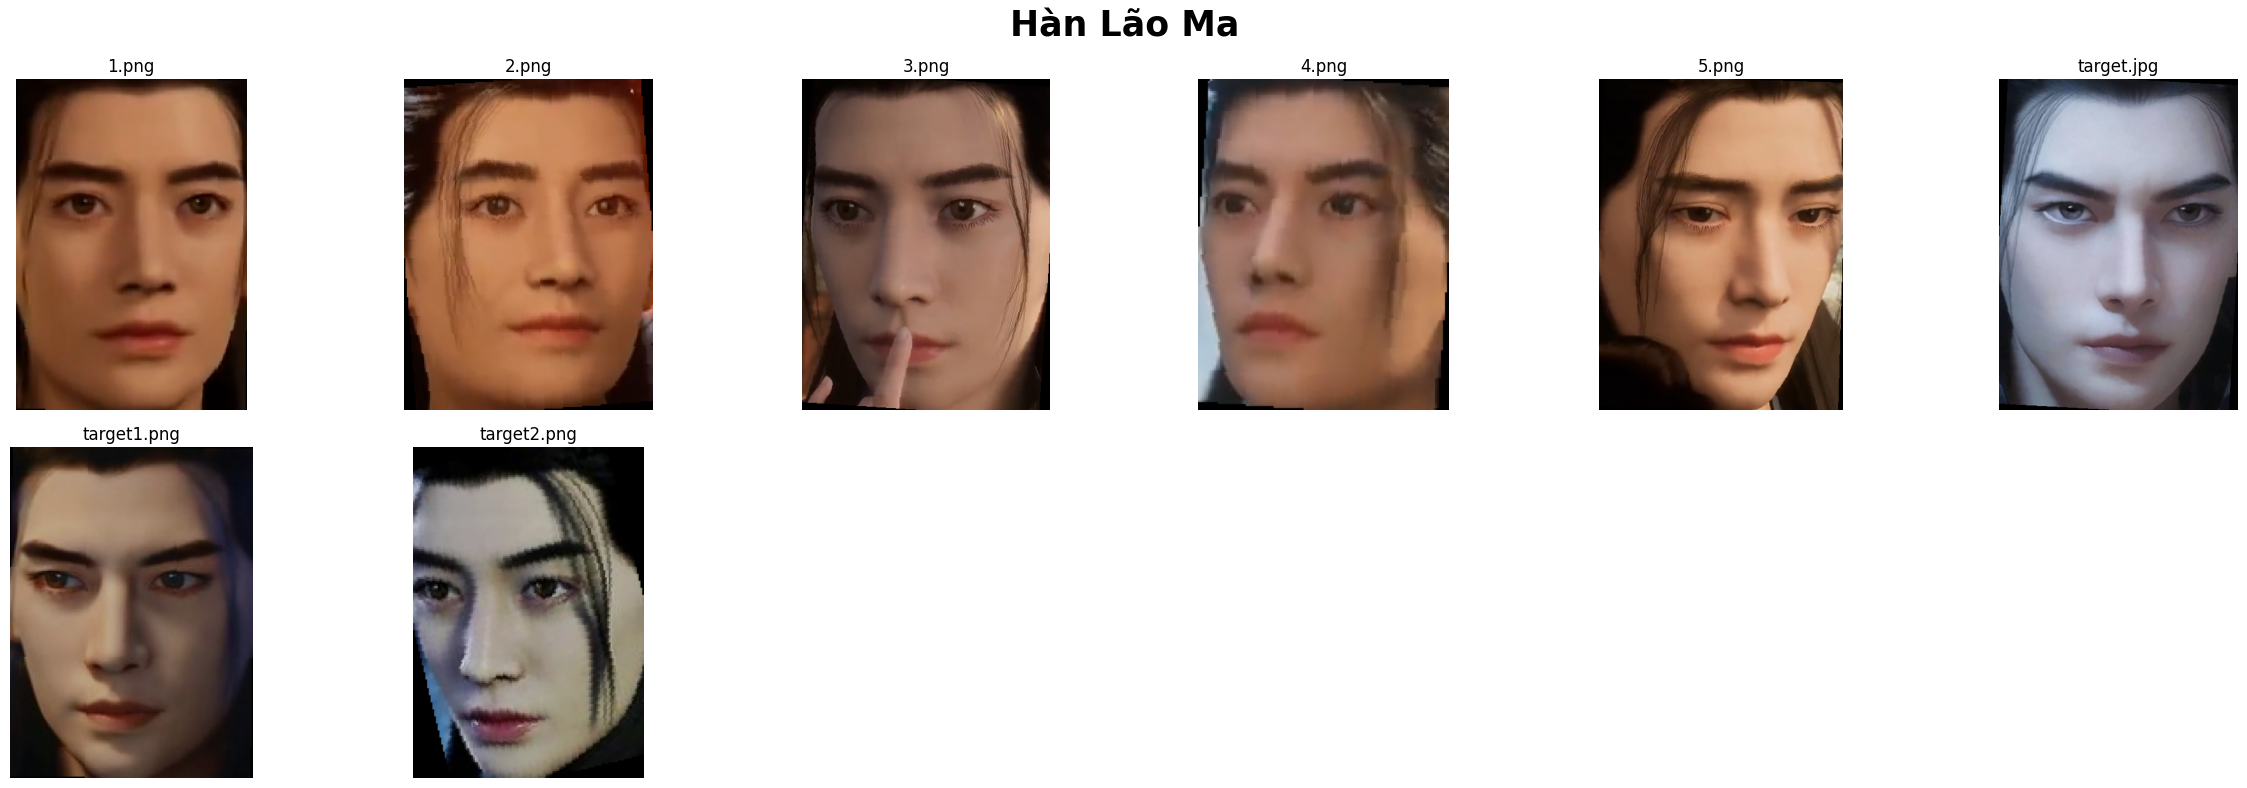

Mean Pooling:  tensor([0.7767], device='cuda:0')
Mean cosine each embedding:  tensor(0.5339, device='cuda:0')






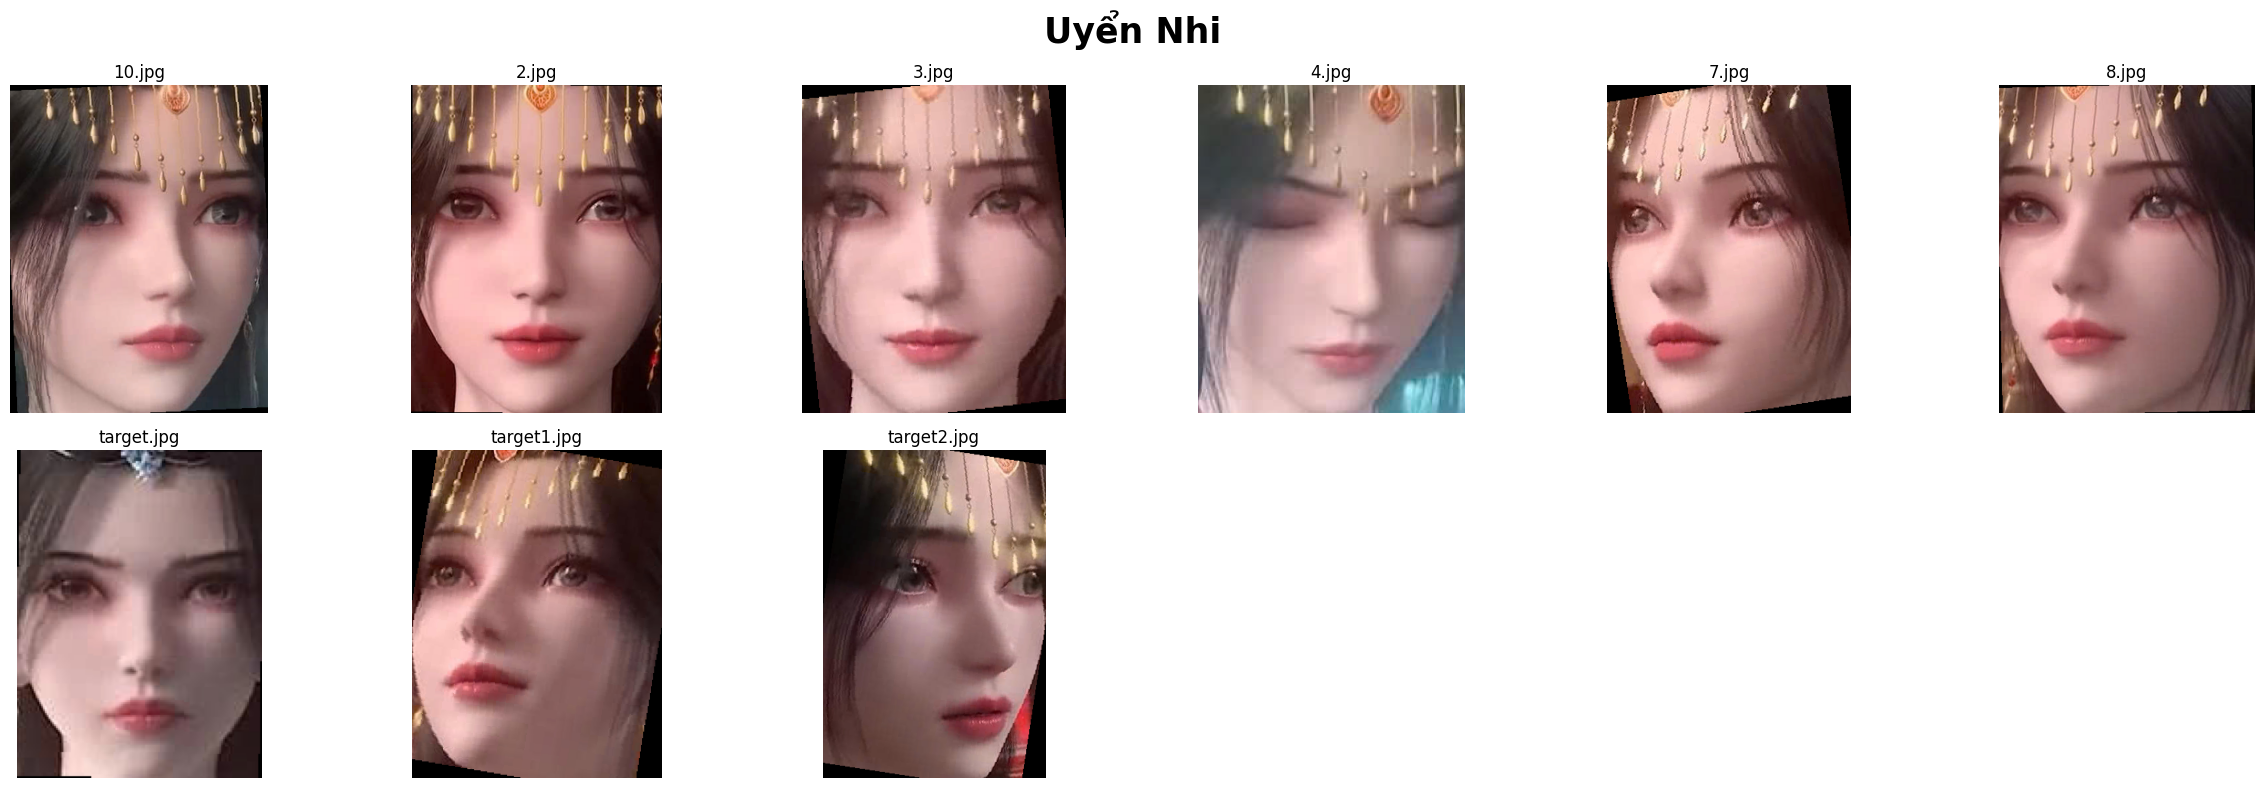

Mean Pooling:  tensor([0.8677], device='cuda:0')
Mean cosine each embedding:  tensor(0.6317, device='cuda:0')






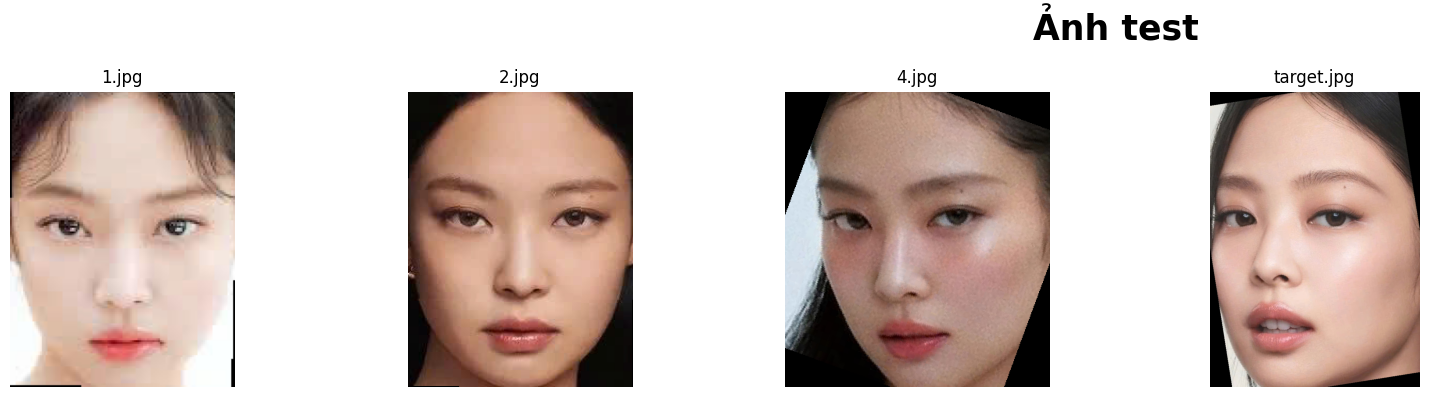

Mean Pooling:  tensor([0.7311], device='cuda:0')
Mean cosine each embedding:  tensor(0.6180, device='cuda:0')




CPU times: total: 1min 4s
Wall time: 8.5 s


In [69]:
%%time
ying(r'xiaoying\images')

In [70]:
def get_images_from_dir(root):
    images = []
    for file in os.listdir(root):
        img_path = os.path.join(root, file)
        img = cv2.imdecode(
            np.fromfile(img_path, dtype=np.uint8),
            cv2.IMREAD_COLOR
        )
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        images.append(transform(img))
    
    return torch.stack(images)

In [54]:
images1 = get_images_from_dir(r'xiaoying\images\Uyển Nhi')
images2 = get_images_from_dir(r'xiaoying\images\Ảnh test')

In [71]:
model.eval()
with torch.no_grad():
    embeds1, _ = model(images1.to(device))
    embeds2, _ = model(images2.to(device))

In [72]:
cosine = torch.cosine_similarity(
    torch.mean(embeds1, dim=0, keepdim=True),
    torch.mean(embeds2, dim=0, keepdim=True)
)
print("Mean Pooling: ", cosine)
        
cosines = torch.cosine_similarity(
    embeds1.unsqueeze(1),
    embeds2.unsqueeze(0),
    dim=-1
)

score = cosines.mean()
print("Mean cosine each embedding: ", score)

Mean Pooling:  tensor([0.3869], device='cuda:0')
Mean cosine each embedding:  tensor(0.1435, device='cuda:0')
